In [1]:
# this walk-through was adapted from the following two tutorials, check them out for more info:
# https://machinelearningmastery.com/machine-learning-in-python-step-by-step/
# https://towardsdatascience.com/exploring-classifiers-with-python-scikit-learn-iris-dataset-2bcb490d2e1b


import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import metrics
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Import and examine data

In [2]:
iris = pd.read_csv("iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
iris.shape

(150, 5)

In [4]:
iris.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [5]:
iris["class"].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

# Data formatting

In [6]:
train, test = train_test_split(iris, test_size = .3, stratify = iris['class'], random_state = 0)
# splits the data into a training and testing set
# test_size = .3 makes the test set 30% of the data
# stratify = iris['class'] makes the classes equally represented in the training/testing sets
# setting a random state ensures that the data will be divided the same way each time

In [7]:
train["class"].value_counts()
# in fact we do have balanced training/testing classes

class
Iris-virginica     35
Iris-setosa        35
Iris-versicolor    35
Name: count, dtype: int64

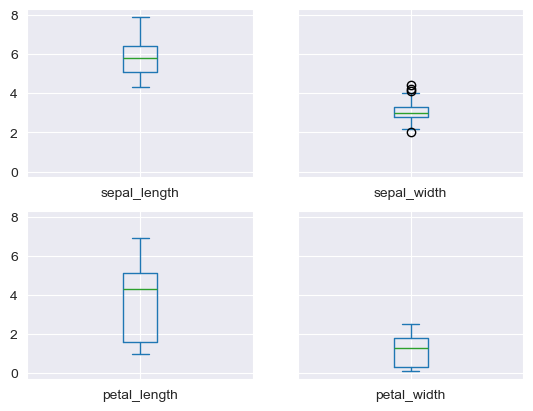

In [8]:
# lets visualize the training set
train.plot(kind = "box", subplots = True, layout = (2,2), sharey = True)
plt.show()

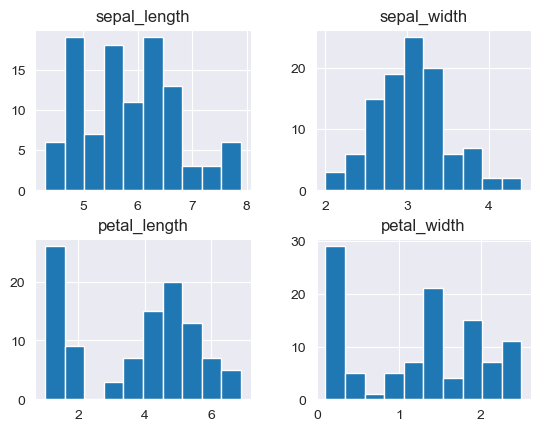

In [9]:
train.hist()
plt.show()

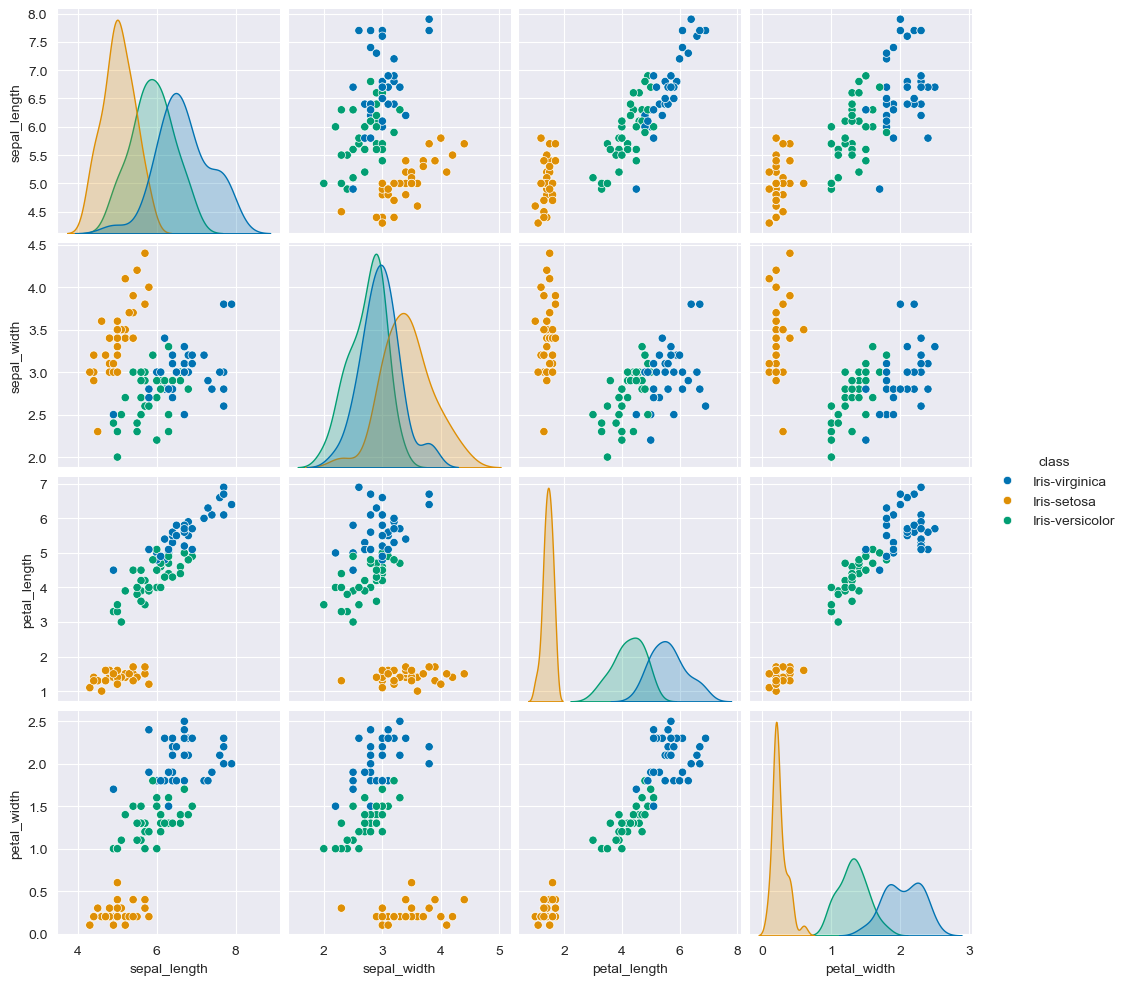

In [10]:
sns.pairplot(train, hue="class", palette = 'colorblind')
plt.show()

# Build a model

In [11]:
# split yourdata sets into predictive attributs (x)
# and the class you are trying to predict (y)

x_train = train[['sepal_length','sepal_width', 'petal_length', 'petal_width']]
y_train = train['class']

x_test = test[['sepal_length','sepal_width', 'petal_length', 'petal_width']]
y_test = test['class']

#first model we will try is a decision tree
mod_dt = DecisionTreeClassifier(max_depth = 3,random_state = 1) #declare model "estimator"
mod_dt.fit(x_train,y_train) #fit the model to your data
y_pred=mod_dt.predict(x_test) #use your "fitted" model to predict labels for the test data
print(y_pred)

['Iris-virginica' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-versicolor' 'Iris-setosa' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-versicolor' 'Iris-virginica' 'Iris-setosa' 'Iris-versicolor'
 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica' 'Iris-virginica'
 'Iris-versicolor' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa' 'Iris-versicolor'
 'Iris-setosa' 'Iris-virginica' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica']


In [12]:
# how good was the model at predicting?
metrics.accuracy_score(y_pred,y_test)

0.9555555555555556

In [13]:
mod_dt.feature_importances_

array([0.0093633 , 0.        , 0.02431926, 0.96631744])

In [14]:
print(mod_dt.classes_)
print(x_train.columns)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width'], dtype='object')


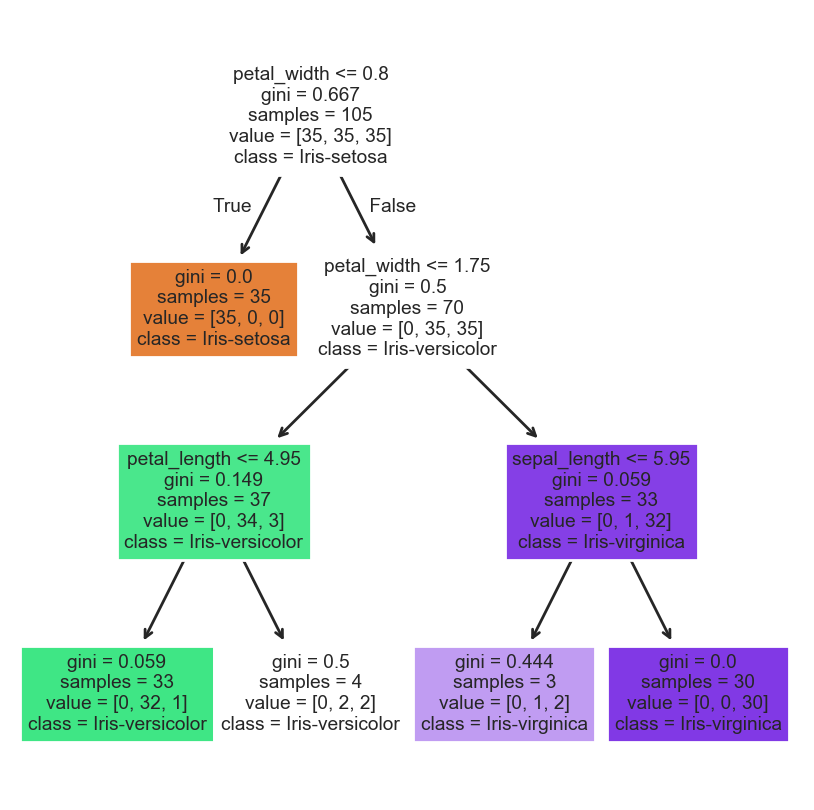

In [15]:
#lets visualize the tree
plt.figure(figsize = (5,5), dpi = 200)
plot_tree(mod_dt,feature_names=x_train.columns,class_names=mod_dt.classes_, filled = True)
plt.show()

In [16]:
#lets look at precision, recall, and F1
print(metrics.classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.88      1.00      0.94        15
 Iris-virginica       1.00      0.87      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



# Lets try a different model
Naive Bayes!

In [17]:
mod_nb = GaussianNB()
mod_nb.fit(x_train,y_train) #fit the model to your data
y_pred2=mod_nb.predict(x_test) #use your "fitted" model to predict labels for the test data
# how good was the model at predicting?
metrics.accuracy_score(y_pred2,y_test)

0.9777777777777777

In [18]:
#refit the model with just the petal attributes

mod_nb.fit(x_train[["petal_length", "petal_width"]], y_train)
y_pred3 = mod_nb.predict(x_test[["petal_length", "petal_width"]])
print("accuracy: ", metrics.accuracy_score(y_pred3,y_test))
#lets look at precision, recall, and F1
print(metrics.classification_report(y_test, y_pred3))

accuracy:  1.0
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      1.00      1.00        15
 Iris-virginica       1.00      1.00      1.00        15

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



The model does **better** using only two features. This implies that the model may be "overfitting" when using all 4 features

# What if we randomly got a bad "split" of the data into training and testing sets?
There are solutions to this problem, one of the most common is called **k-fold cross validation**. K-fold cross validation divides your data into k smaller data sets, then trains the model on k different subsets of the data.

Lets test out a few different models using k-fold cross validation

In [19]:
# Different models to test
models = []
models.append(('LR', LogisticRegression(solver='liblinear', multi_class='ovr')))
models.append(('KNN', KNeighborsClassifier()))
models.append(('DT', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC(gamma='auto')))
# evaluate each model in turn
results = []
names = []
for name, model in models:
    kfold = StratifiedKFold(n_splits=5, random_state=1, shuffle=True)
    cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    print(name, round(cv_results.mean(),3), round(cv_results.std(),3))

LR 0.952 0.052
KNN 0.933 0.038
DT 0.905 0.052
NB 0.952 0.03
SVM 0.943 0.047


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_clas

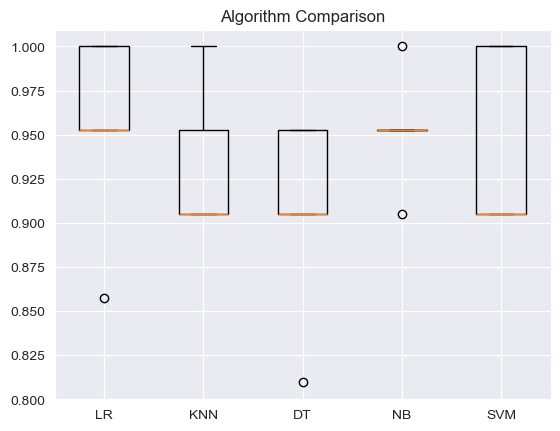

In [20]:
plt.boxplot(results, tick_labels=names)
plt.title('Algorithm Comparison')
plt.show()

# Your turn: build a model to predict basketball games!
Download the basketballData.csv file from Canvas. Choose what features (columns) you think are most predictive and choose a model from above and try to build the best model you can! Remember, the basic format for modeling in python is:

1) divide your data into a training and testing set

2) declare a model esitmator

3) "fit" the model

4) evaluate the model

For information about what each column means, see: https://www.sports-reference.com/cbb/seasons/2021-school-stats.html

The first step has already been done for you below. The column you are interested in predicting is 'Team1Win?'. Don't worry about trying to do k-fold cross validation. Just choose parameters and try it out!

In [21]:
basketballData = pd.read_csv("basketballData.csv")
pd.set_option("display.max.columns", None)
basketballData = basketballData.drop(["Unnamed: 0", "Year", "Team1", "Team2"], axis=1)

basketballData.head()

,Team1Win?,Team1Wins,Team1SRS,Team1ORtg,Team1TS%,Team1eFG%,Team1OppORtg,Team1OppTS%,Team1OppeFG%,Team1Pace,Team1TRB%,Team1AST%,Team1TOV%,Team1Steal%,Team1Block%,Team2Wins,Team2SRS,Team2ORtg,Team2TS%,Team2eFG%,Team2OppORtg,Team2OppTS%,Team2OppeFG%,Team2Pace,Team2TRB%,Team2AST%,Team2TOV%,Team2Steal%,Team2Block%
0,0,31,8.69,112.4,0.586,0.556,88.8,0.477,0.436,68.0,54.7,56.9,18.3,14.2,14.2,24,17.29,113.4,0.571,0.533,100.1,0.517,0.483,67.9,52.5,51.8,15.1,8.3,6.3
1,1,20,10.14,102.2,0.511,0.480,98.6,0.499,0.471,72.4,53.4,57.0,17.2,9.3,13.5,7,-12.81,97.8,0.499,0.462,111.0,0.586,0.558,69.0,46.9,50.5,16.6,11.4,5.3
2,1,29,19.49,113.0,0.586,0.561,93.8,0.501,0.471,65.1,51.2,55.4,15.0,10.8,12.2,2,-30.36,80.2,0.456,0.418,108.5,0.548,0.523,75.3,44.5,41.3,23.7,9.1,7.4
3,0,7,-11.94,94.8,0.503,0.465,104.4,0.530,0.497,65.7,52.0,53.5,20.6,8.8,8.2,30,21.72,114.0,0.596,0.576,93.5,0.482,0.459,71.0,53.0,64.6,18.3,13.5,17.2
4,0,20,1.35,100.7,0.534,0.500,95.3,0.510,0.469,68.4,52.9,56.0,19.4,10.9,10.9,24,17.29,113.4,0.571,0.533,100.1,0.517,0.483,67.9,52.5,51.8,15.1,8.3,6.3


In [22]:
#divide into training and testing
train, test = train_test_split(basketballData, test_size = .2, stratify = basketballData['Team1Win?'], random_state = 0)

# model_attributes = ["Team1Wins", "Team2Wins"] #add your desired columns here!
model_attributes = basketballData.drop("Team1Win?", axis=1).columns
#divide into x and y
x_train = train[model_attributes]
y_train = train["Team1Win?"]

x_test = test[model_attributes]
y_test = test["Team1Win?"]

#build your model
mod_bball_lr = LogisticRegression(solver='liblinear', multi_class='ovr') #feel free to swap this model for another one from above!
mod_bball_lr.fit(x_train, y_train)
bball_pred_lr = mod_bball_lr.predict(x_test)
print("accuracy lr: ", metrics.accuracy_score(bball_pred_lr, y_test))

mod_bball_nb = GaussianNB()
mod_bball_nb.fit(x_train, y_train)
bball_pred_nb = mod_bball_nb.predict(x_test)
print("accuracy nb: ", metrics.accuracy_score(bball_pred_nb, y_test))

mod_bball_dt = DecisionTreeClassifier(max_depth = 3,random_state = 1)
mod_bball_dt.fit(x_train, y_train)
bball_pred_dt = mod_bball_dt.predict(x_test)
print("accuracy dt: ", metrics.accuracy_score(bball_pred_dt,y_test))


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


accuracy lr:  0.7657563025210085
accuracy nb:  0.7404411764705883
accuracy dt:  0.7289915966386554
